**サイドバックの攻撃参加はチームに貢献するのか**
-
ー上位進出国の5選手の比較ー


#**1.はじめに**

##1.1 研究背景

近年のサッカーにおいて、サイドバックは守備だけでなく攻撃面での貢献も求められるポジションとなっている。特に現代サッカーでは、サイドバックが高い位置を取り、チャンス創出やビルドアップに関与する場面が増えている。そのため、サイドバックの攻撃参加がチームの成績にどのような影響を与えるのかは興味深いテーマである。

私自身、現在社会人サッカーチームで右サイドバックとしてプレーしている。試合の中では攻撃参加を求められる一方で、守備とのバランスやチーム戦術に応じた役割の変化を感じる場面が多い。この経験から、サイドバックの攻撃参加とチーム成績の関係についてデータを用いて客観的に分析したいと考え、本研究に取り組んだ。

#1.2 研究目的

本研究では、2022 FIFAワールドカップにおける上位進出国の右サイドバック5選手を対象に、パス数、前進パス数、ボールキャリー数、クロス数、ラストパス数、アシスト数などの攻撃指標を分析する。そして、攻撃参加の特徴とチーム成績との関係を考察し、現代サッカーにおける右サイドバックの役割について検討することを目的とする。

#**2.分析対象**


1.   対象選手

*   ハキミ(モロッコ)
*   トリッピアー(イングランド)
*   モリーナ(アルゼンチン)
*   クンデ(フランス)
*   ダンフリース(オランダ)

2.   データソース
*   StatsBomb Open Data
*   2022 FIFA World Cup




#**3.分析指標および集計結果**


本研究では、選手ごとの攻撃参加の特徴を定量的に比較するため、以下の指標を用いた。


*   パス数
*  パス成功数
*   前進パス数
*   ボールキャリー数
*   クロス数
*   ラストパス数
*   アシスト数


In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
%%capture
!pip install statsbombpy pandas
!pip install mplsoccer -q
!pip install japanize-matplotlib -q

In [34]:
import pandas as pd
import numpy as np
from statsbombpy import sb
from tqdm import tqdm
from IPython.display import clear_output

# 検索用の名前と表示用の名前
player_map = {
    'Hakimi': 'ハキミ',
    'Trippier': 'トリッピアー',
    'Molina': 'モリーナ',
    'Kound': 'クンデ',
    'Dumfries': 'ダンフリース'
}

# 敵陣ゴールの座標
GOAL_X = 120
GOAL_Y = 40

def calculate_distance_to_goal(location):
    if not isinstance(location, list) or len(location) < 2:
        return np.nan
    x, y = location[0], location[1]
    return np.sqrt((GOAL_X - x)**2 + (GOAL_Y - y)**2)

# 試合データの取得（2022W杯）
matches = sb.matches(competition_id=43, season_id=106)

player_stats = {name: {'総パス数': 0, '成功パス数': 0, '前進パス数': 0, 'ボールキャリー数': 0, 'クロス数': 0, 'ラストパス数': 0, 'アシスト数': 0}
                for name in player_map.values()}

print("全64試合から対象5選手のデータを抽出中...")

for idx, row in tqdm(matches.iterrows(), total=len(matches)):
    match_id = row['match_id']
    try:
        events = sb.events(match_id=match_id)
    except:
        continue

    # パスイベントとキャリー（持ち運び）イベントをそれぞれ抽出
    passes = events[events['type'] == 'Pass'].copy().dropna(subset=['player'])
    carries = events[events['type'] == 'Carry'].copy().dropna(subset=['player'])

    for search_name, display_name in player_map.items():
        # --- パス関連の集計 ---
        player_passes = passes[passes['player'].str.contains(search_name, na=False)]

        if len(player_passes) > 0:
            player_stats[display_name]['総パス数'] += len(player_passes)

            successful_passes = player_passes[player_passes['pass_outcome'].isna()].copy()
            player_stats[display_name]['成功パス数'] += len(successful_passes)

            if 'pass_cross' in successful_passes.columns:
                player_stats[display_name]['クロス数'] += successful_passes['pass_cross'].sum()

            if 'pass_goal_assist' in successful_passes.columns:
                player_stats[display_name]['アシスト数'] += successful_passes['pass_goal_assist'].sum()

            # ラストパスの集計
            if 'pass_shot_assist' in successful_passes.columns:
                player_stats[display_name]['ラストパス数'] += successful_passes['pass_shot_assist'].fillna(False).sum()

            if 'location' in successful_passes.columns and 'pass_end_location' in successful_passes.columns:
                start_dist = successful_passes['location'].apply(calculate_distance_to_goal)
                end_dist = successful_passes['pass_end_location'].apply(calculate_distance_to_goal)
                is_progressive = end_dist < (start_dist * 0.75)
                player_stats[display_name]['前進パス数'] += is_progressive.sum()

        # --- ボールキャリーの集計 ---
        player_carries = carries[carries['player'].str.contains(search_name, na=False)]

        if len(player_carries) > 0:
            # キャリーの開始位置(location)と終了位置(carry_end_location)が存在するか確認
            if 'location' in player_carries.columns and 'carry_end_location' in player_carries.columns:
                # キャリー終了位置のカラムはリストや辞書型で入っていることがあるため整形
                carry_end = player_carries['carry_end_location'].apply(
                    lambda x: x if isinstance(x, list) else (x if isinstance(x, tuple) else [np.nan, np.nan])
                )

                c_start_dist = player_carries['location'].apply(calculate_distance_to_goal)
                c_end_dist = carry_end.apply(calculate_distance_to_goal)

                # パスと同じ基準（25%以上ゴールに近づく）で前進キャリーを判定
                is_progressive_carry = c_end_dist < (c_start_dist * 0.75)
                player_stats[display_name]['ボールキャリー数'] += is_progressive_carry.sum()

# 抽出の進捗バーなどを綺麗に消す
clear_output()

# データフレームに変換して表示
df_results = pd.DataFrame(player_stats).T
display(df_results)

,総パス数,成功パス数,前進パス数,ボールキャリー数,クロス数,ラストパス数,アシスト数
ハキミ,380,314,23,10,5,6,1
トリッピアー,195,165,22,0,1,3,0
モリーナ,360,296,22,8,3,2,1
クンデ,308,258,18,4,1,2,0
ダンフリース,218,148,28,11,3,0,2


これらの指標は、選手の出場時間が異なることによる影響を除外するため、すべて90分あたりの値に換算して比較を行った。

In [35]:
import pandas as pd
import numpy as np
from statsbombpy import sb
from tqdm import tqdm
from IPython.display import clear_output

player_map = {
    'Hakimi': 'ハキミ',
    'Trippier': 'トリッピアー',
    'Molina': 'モリーナ',
    'Kound': 'クンデ',
    'Dumfries': 'ダンフリース'
}

GOAL_X = 120
GOAL_Y = 40

def calculate_distance_to_goal(location):
    if not isinstance(location, list) or len(location) < 2:
        return np.nan
    x, y = location[0], location[1]
    return np.sqrt((GOAL_X - x)**2 + (GOAL_Y - y)**2)

matches = sb.matches(competition_id=43, season_id=106)

# 選手ごとの集計用辞書
player_stats = {name: {
    '総出場時間(分)': 0,
    '総パス数': 0,
    '成功パス数': 0,
    '前進パス数': 0,
    'ボールキャリー数': 0,
    'クロス数': 0,
    'ラストパス数': 0,
    'アシスト数': 0
} for name in player_map.values()}

print("全64試合から対象5選手の出場時間とスタッツを抽出中...")

for idx, row in tqdm(matches.iterrows(), total=len(matches)):
    match_id = row['match_id']
    try:
        events = sb.events(match_id=match_id)
    except:
        continue

    max_match_minute = events['minute'].max()

    # 処理を軽くするため、先にパスとキャリーの全イベントを分けておく
    passes = events[events['type'] == 'Pass'].copy()
    carries = events[events['type'] == 'Carry'].copy()

    # 検索用キーを使ってループ
    for search_name, display_name in player_map.items():
        # 対象選手の全イベントを取得
        player_events = events[events['player'].str.contains(search_name, na=False)]
        if len(player_events) == 0:
            continue

        full_name = player_events['player'].iloc[0]

        # 出場時間の計算
        start_min, end_min = 0, max_match_minute
        sub_out = events[(events['type'] == 'Substitution') & (events['player'] == full_name)]
        if len(sub_out) > 0: end_min = sub_out['minute'].iloc[0]
        if 'substitution_replacement' in events.columns:
            sub_in = events[(events['type'] == 'Substitution') & (events['substitution_replacement'] == full_name)]
            if len(sub_in) > 0: start_min = sub_in['minute'].iloc[0]

        match_mins = max(0, end_min - start_min)
        player_stats[display_name]['総出場時間(分)'] += match_mins

        # --- パス関連の集計 ---
        player_passes = passes[passes['player'] == full_name]
        successful_passes = player_passes[player_passes['pass_outcome'].isna()].copy()


        player_stats[display_name]['総パス数'] += len(player_passes)
        player_stats[display_name]['成功パス数'] += len(successful_passes)
        player_stats[display_name]['クロス数'] += successful_passes.get('pass_cross', pd.Series(0)).sum()
        player_stats[display_name]['アシスト数'] += successful_passes.get('pass_goal_assist', pd.Series(0)).sum()
        player_stats[display_name]['ラストパス数'] += successful_passes.get('pass_shot_assist', pd.Series(0)).sum()

        if 'location' in successful_passes.columns and 'pass_end_location' in successful_passes.columns:
            start_dist = successful_passes['location'].apply(calculate_distance_to_goal)
            end_dist = successful_passes['pass_end_location'].apply(calculate_distance_to_goal)
            is_progressive = end_dist < (start_dist * 0.75)
            player_stats[display_name]['前進パス数'] += is_progressive.sum()


        player_carries = carries[carries['player'] == full_name]
        if len(player_carries) > 0 and 'location' in player_carries.columns and 'carry_end_location' in player_carries.columns:
            # 終了座標のフォーマットを整える
            carry_end = player_carries['carry_end_location'].apply(
                lambda x: x if isinstance(x, list) else (x if isinstance(x, tuple) else [np.nan, np.nan])
            )
            c_start_dist = player_carries['location'].apply(calculate_distance_to_goal)
            c_end_dist = carry_end.apply(calculate_distance_to_goal)

            # パスと同様に、ゴールまでの距離が25%以上縮まったキャリーをカウント
            is_progressive_carry = c_end_dist < (c_start_dist * 0.75)
            player_stats[display_name]['ボールキャリー数'] += is_progressive_carry.sum()

# プログレスバーなどの出力を消去して画面をクリーンに
clear_output()

# --- 90分あたりの変換処理 ---
df_totals = pd.DataFrame(player_stats).T
df_per90 = pd.DataFrame()
df_per90['総出場時間(分)'] = df_totals['総出場時間(分)']

metrics = ['総パス数', '成功パス数', '前進パス数', 'ボールキャリー数', 'クロス数', 'ラストパス数', 'アシスト数']

# すべての指標を一括で90分換算
for metric in metrics:
    df_per90[f'{metric}_per90'] = (df_totals[metric] / df_totals['総出場時間(分)']) * 90

print("--- 90分あたりの平均スタッツ（Per 90） ---")
display(df_per90.round(2))

--- 90分あたりの平均スタッツ（Per 90） ---


,総出場時間(分),総パス数_per90,成功パス数_per90,前進パス数_per90,ボールキャリー数_per90,クロス数_per90,ラストパス数_per90,アシスト数_per90
ハキミ,660,51.82,42.82,3.14,1.36,0.68,0.82,0.14
トリッピアー,227,77.31,65.42,8.72,0.00,0.40,1.19,0.00
モリーナ,592,54.73,45.00,3.34,1.22,0.46,0.30,0.15
クンデ,512,54.14,45.35,3.16,0.70,0.18,0.35,0.00
ダンフリース,515,38.10,25.86,4.89,1.92,0.52,0.00,0.35


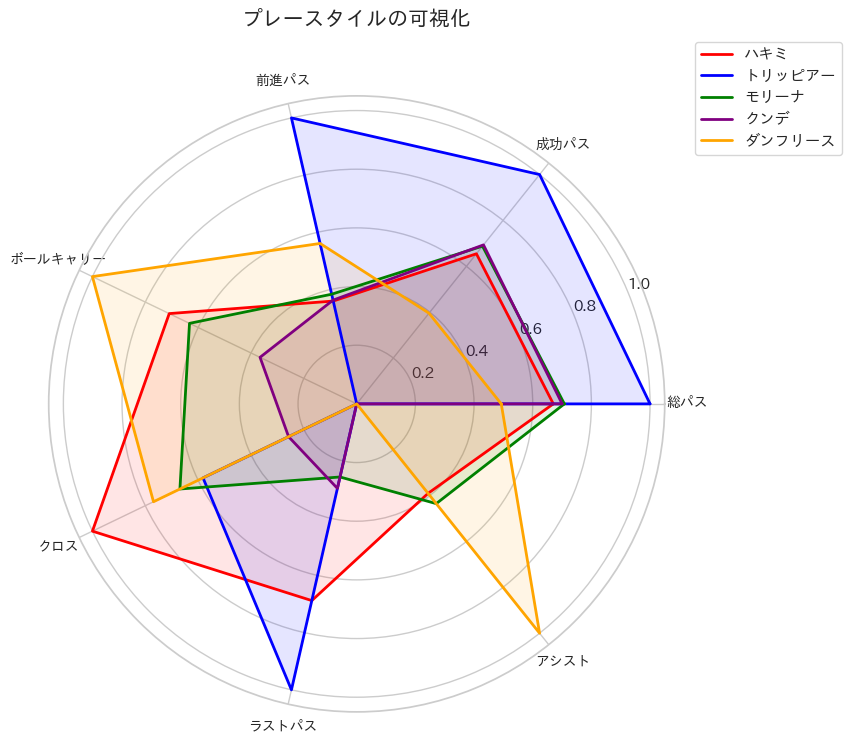

In [36]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import math

# --- レーダーチャートの描画 ---
# 比較したい指標を選択
radar_metrics = ['総パス数_per90', '成功パス数_per90', '前進パス数_per90',
                 'ボールキャリー数_per90', 'クロス数_per90', 'ラストパス数_per90', 'アシスト数_per90']

# 各指標の最大値を1として正規化（グラフの形を比較しやすくするため）
df_radar = df_per90[radar_metrics].copy()
df_normalized = df_radar / df_radar.max()

# プロットの設定
labels = radar_metrics
num_vars = len(labels)
angles = [n / float(num_vars) * 2 * math.pi for n in range(num_vars)]
angles += angles[:1] # 円を閉じるために最初の角度を追加

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 選手のカラー設定
colors = {'ハキミ': 'red', 'トリッピアー': 'blue', 'モリーナ': 'green', 'クンデ': 'purple', 'ダンフリース': 'orange'}

for player in df_normalized.index:
    values = df_normalized.loc[player].tolist()
    values += values[:1] # 円を閉じる

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=player, color=colors[player])
    ax.fill(angles, values, alpha=0.1, color=colors[player])

# 軸とラベルの設定
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['総パス', '成功パス', '前進パス',
                    'ボールキャリー', 'クロス', 'ラストパス', 'アシスト'], fontsize=10)
ax.set_title("プレースタイルの可視化", size=15, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

**データからわかる5選手のプレースタイル**

① トリッピアーは「配球・チャンス創出型」

* 総パス数:77.31（5人中1位）
* 成功パス数:65.42（1位）
* 前進パス数:8.72（圧倒的1位）
* ラストパス数:1.19（1位）

つまりトリッピアーは、自らドリブルで運ぶというよりも、パスによって攻撃を前進させるタイプであると考えられる。

一方で、

* ボールキャリー数:0.00

であり、推進力をキャリーではなくパスで発揮していることが分かる。

⸻

② ハキミは「推進力と創造性を兼ね備えた万能型」

* ボールキャリー前進数:1.36
* クロス数:0.68（1位）
* ラストパス数:0.82（2位）
* アシスト数:0.14

ハキミはトリッピアーほどパスを出すわけではないが、自身のスピードを活かしたドリブル突破やクロスによって攻撃に関与している。

モロッコのベスト4進出を支えた要因の一つとして、ハキミの攻撃参加が挙げられる可能性がある。

⸻

③ モリーナは「バランス型」

ほぼ全項目で平均以上。

* 総パス数:54.73
* 成功パス数:45.00
* 前進パス数:3.34
* ボールキャリー数:1.22
* アシスト数:0.15

突出した数値はないが、攻撃のあらゆる局面に関与している。

実際に優勝したアルゼンチンでは、モリーナは攻撃と守備の両面で安定した働きを見せていた。

⸻

④ クンデは「守備・ビルドアップ型」

* 総パス数:54.14
* 成功パス数:45.35
* 前進パス数:3.16

は一定水準にある。

しかし、

* クロス数:0.18
* キーパス数:0.35
* アシスト数:0

と攻撃面の数値は控えめ。

本職がセンターバックであることから、フランス代表では攻撃参加よりも守備の安定や後方からの組み立てを重視した役割を担っていたと考えられる。

⸻

⑤ ダンフリースは「フィニッシュ関与型」

興味深いのがダンフリース。

* 総パス数:38.10（最少）
* 成功パス数:25.86（最少）

にもかかわらず、

* ボールキャリー数:1.92（1位）
* アシスト数:0.35（1位）

である。

つまりダンフリースはビルドアップに関与するタイプではなく、高い位置まで進出して決定機に直接関与するタイプのサイドバックと考えられる。




---


また、攻撃参加指数といった独自の新しい定義を加える。


$$ \text{攻撃参加指数} = (\text{前進パス}{/90}) + (\text{ボールキャリー}{/90}\times 2)+(\text{クロス}{/90} \times 3) +(\text{ラストパス}{/90} \times 5)+ (\text{アシスト}{/90} \times 20) $$



本指標の設計にあたっては、各アクションのゴールへの直接的な寄与度と、試合中における発生頻度（希少性）を考慮した。




*   前進パス (1倍)

ビルドアップやチャンスメイクの起点となる基本的な攻撃アクションであり、試合中も頻繁に発生するため基準値とした。

*   ボールキャリー数 (2倍)

自らボールを運ぶプレーは、相手の守備を引き剥がして新たなスペースを生み出します。個人の推進力による局面打開を評価し、前進パスより高い数値に設定した。

*   クロス(3倍)

ペナルティエリア内への供給は、シュートに至る直接的な確率を高めるため、前進パス、ボールキャリーよりも高い評価を与えた。


*   ラストパス数 (5倍):

味方のシュートに直結するパスであり、単なるクロスよりも明確な決定機を創出するため、5倍に設定した。



*   アシスト (20倍)

得点に直結する決定的なプレーは試合における最重要アクションであり、その発生頻度の低さと価値の高さから最も大きな係数を設定した。


このように、単一のスタッツではなく、プレーの「質」に応じた重み付けを行うことで、各選手の攻撃スタイルとチーム戦術への貢献度を客観的に比較可能とした。

In [37]:
# ユーザー定義の独自指標「攻撃参加指数」を計算
df_per90['攻撃参加指数'] = (
    df_per90['前進パス数_per90'] * 1 +
    df_per90['ボールキャリー数_per90'] * 2 +
    df_per90['クロス数_per90'] * 3 +
    df_per90['ラストパス数_per90'] * 5 +
    df_per90['アシスト数_per90'] * 20
).round(2)

# 攻撃参加指数が高い順（降順）に並び替えて表示
df_ranked = df_per90.sort_values('攻撃参加指数', ascending=False)

print("--- 独自の「攻撃参加指数」ランキング ---")
display(df_ranked[['前進パス数_per90', 'ボールキャリー数_per90','クロス数_per90','ラストパス数_per90', 'アシスト数_per90', '攻撃参加指数']])

--- 独自の「攻撃参加指数」ランキング ---


,前進パス数_per90,ボールキャリー数_per90,クロス数_per90,ラストパス数_per90,アシスト数_per90,攻撃参加指数
ダンフリース,4.893204,1.922330,0.524272,0.000000,0.349515,17.30
トリッピアー,8.722467,0.000000,0.396476,1.189427,0.000000,15.86
ハキミ,3.136364,1.363636,0.681818,0.818182,0.136364,14.73
モリーナ,3.344595,1.216216,0.456081,0.304054,0.152027,11.71
クンデ,3.164062,0.703125,0.175781,0.351562,0.000000,6.86


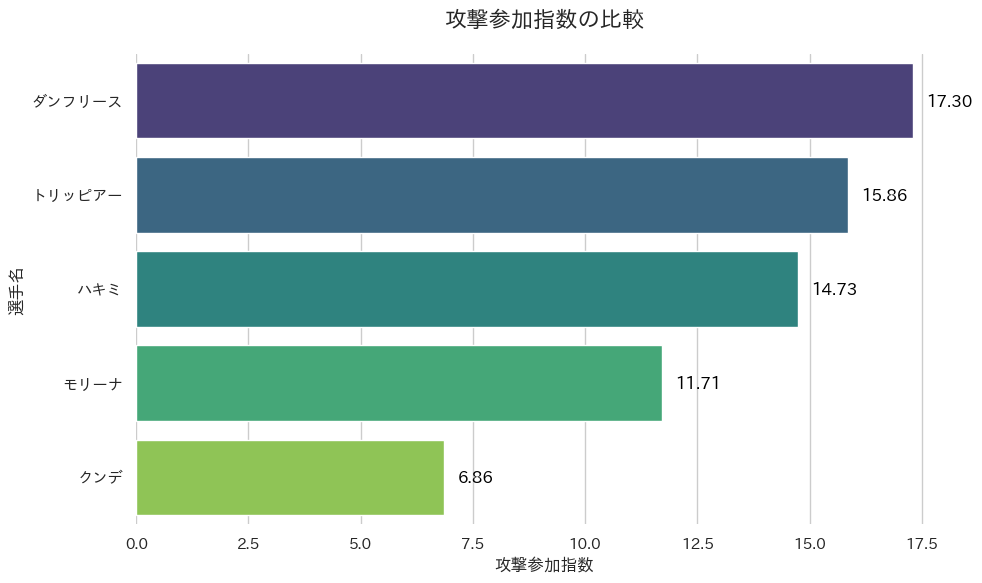

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# グラフの全体的なスタイルを設定
sns.set_theme(style="whitegrid")
japanize_matplotlib.japanize()

# グラフのサイズを設定
plt.figure(figsize=(10, 6))

# seabornを使って横向き棒グラフを描画
# 順位がわかりやすいように、攻撃参加指数によって色をグラデーション（viridis）にする
ax = sns.barplot(
    x='攻撃参加指数',
    y=df_ranked.index,
    data=df_ranked,
    palette='viridis'
)

# タイトルと軸ラベルの設定
plt.title('攻撃参加指数の比較', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('攻撃参加指数', fontsize=12)
plt.ylabel('選手名', fontsize=12)

# 棒の右側に実際の数値を表示する処理
for i, v in enumerate(df_ranked['攻撃参加指数']):
    ax.text(v + 0.3, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

# グラフの枠線を消してスッキリ見せる
sns.despine(left=True, bottom=True)

# 描画
plt.tight_layout()
plt.show()

#**4.【深掘り分析】戦術的非対称性の証明:フランス代表の左右SB比較**

先の分析において、クンデの攻撃指標が他国の選手と比較して著しく低いことが確認された。この数値の背景にある「戦術的コンテキスト」を明らかにするため、本論の裏付けとしてフランス代表の左右のサイドバック（右：クンデ、左：テオ・エルナンデス）のスタッツを比較し、戦術的な役割分担がどのように数値に表れているかを分析する。

フランス代表 両サイドバックのデータを抽出中...


100%|██████████| 64/64 [00:18<00:00,  3.55it/s]


--- フランス代表 左右サイドバックの攻撃指標比較 ---


,前進パス数_per90,ボールキャリー数_per90,クロス数_per90,ラストパス数_per90,攻撃参加指数
クンデ (右SB),3.164062,0.703125,0.175781,0.351562,6.86
テオ (左SB),3.626374,1.978022,0.989011,1.648352,25.38


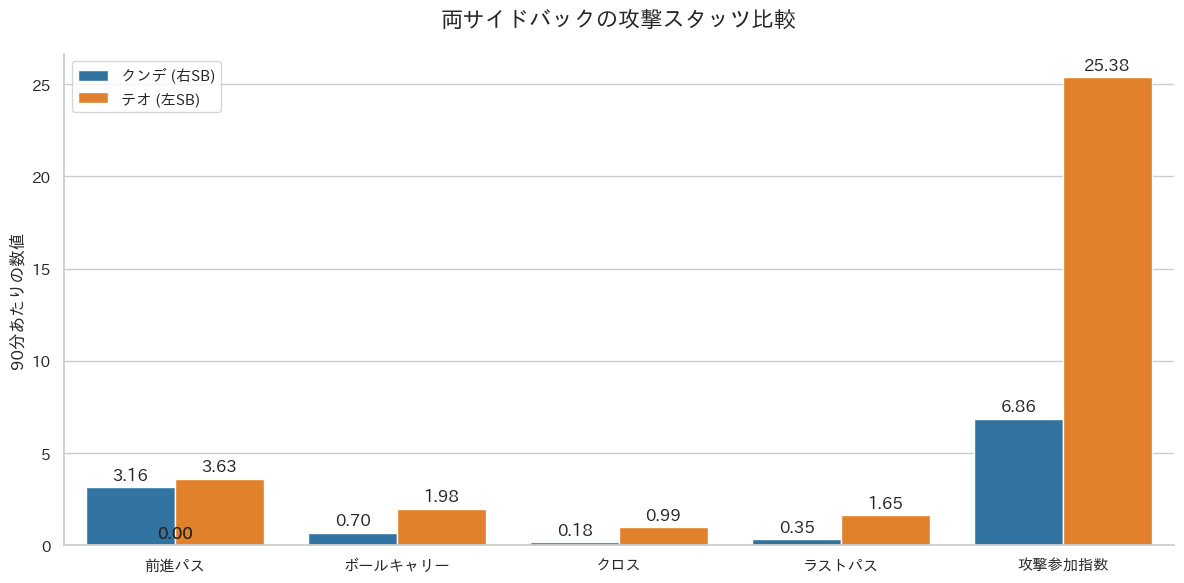

In [39]:
import pandas as pd
import numpy as np
from statsbombpy import sb
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# ターゲット選手（フランス代表の左右のSB）
target_players = ['Kound', 'Theo'] # Kounde と Theo Hernandez

GOAL_X = 120
GOAL_Y = 40

def calculate_distance_to_goal(location):
    if not isinstance(location, list) or len(location) < 2:
        return np.nan
    x, y = location[0], location[1]
    return np.sqrt((GOAL_X - x)**2 + (GOAL_Y - y)**2)

matches = sb.matches(competition_id=43, season_id=106)

player_stats = {player: {
    '総出場時間(分)': 0, '前進パス数': 0, 'ボールキャリー数': 0, 'クロス数': 0, 'ラストパス数': 0, 'アシスト数': 0
} for player in target_players}

print("フランス代表 両サイドバックのデータを抽出中...")

for idx, row in tqdm(matches.iterrows(), total=len(matches)):
    match_id = row['match_id']
    try:
        events = sb.events(match_id=match_id)
    except:
        continue

    max_match_minute = events['minute'].max()

    for target in target_players:
        player_events = events[events['player'].str.contains(target, na=False)]
        if len(player_events) == 0:
            continue

        full_name = player_events['player'].iloc[0]
        start_min = 0
        end_min = max_match_minute

        sub_out = events[(events['type'] == 'Substitution') & (events['player'] == full_name)]
        if len(sub_out) > 0:
            end_min = sub_out['minute'].iloc[0]

        if 'substitution_replacement' in events.columns:
            sub_in = events[(events['type'] == 'Substitution') & (events['substitution_replacement'] == full_name)]
            if len(sub_in) > 0:
                start_min = sub_in['minute'].iloc[0]

        match_mins = max(0, end_min - start_min)
        player_stats[target]['総出場時間(分)'] += match_mins

        # --- パス関連の抽出 ---
        player_passes = player_events[player_events['type'] == 'Pass']
        successful_passes = player_passes[player_passes['pass_outcome'].isna()].copy()

        if 'pass_cross' in successful_passes.columns:
            player_stats[target]['クロス数'] += successful_passes['pass_cross'].sum()

        if 'pass_goal_assist' in successful_passes.columns:
            player_stats[target]['アシスト数'] += successful_passes['pass_goal_assist'].sum()

        # ラストパスの抽出を追加
        if 'pass_shot_assist' in successful_passes.columns:
            # StatsBombではTrue/NaNで入っているため、Trueの数を合計
            player_stats[target]['ラストパス数'] += successful_passes['pass_shot_assist'].fillna(False).sum()

        # 前進パスの抽出
        if 'location' in successful_passes.columns and 'pass_end_location' in successful_passes.columns:
            start_dist = successful_passes['location'].apply(calculate_distance_to_goal)
            end_dist = successful_passes['pass_end_location'].apply(calculate_distance_to_goal)
            is_progressive = end_dist < (start_dist * 0.75)
            player_stats[target]['前進パス数'] += is_progressive.sum()

        # --- ボールキャリー関連の抽出を追加 ---
        player_carries = player_events[player_events['type'] == 'Carry'].copy()
        if len(player_carries) > 0 and 'location' in player_carries.columns and 'carry_end_location' in player_carries.columns:
            start_dist_carry = player_carries['location'].apply(calculate_distance_to_goal)
            end_dist_carry = player_carries['carry_end_location'].apply(calculate_distance_to_goal)
            is_progressive_carry = end_dist_carry < (start_dist_carry * 0.75)
            player_stats[target]['ボールキャリー数'] += is_progressive_carry.sum()

# データフレーム化とPer90計算
df_fra = pd.DataFrame(player_stats).T
df_fra_per90 = pd.DataFrame()
df_fra_per90['総出場時間(分)'] = df_fra['総出場時間(分)']

# 90分換算する対象リストを拡張
metrics_to_per90 = ['前進パス数', 'ボールキャリー数', 'クロス数', 'ラストパス数', 'アシスト数']
for metric in metrics_to_per90:
    df_fra_per90[f'{metric}_per90'] = (df_fra[metric] / df_fra['総出場時間(分)']) * 90

df_fra_per90['攻撃参加指数'] = (
    df_fra_per90['前進パス数_per90'] * 1 +
    df_fra_per90['ボールキャリー数_per90'] * 2 +
    df_fra_per90['クロス数_per90'] * 3 +
    df_fra_per90['ラストパス数_per90'] * 5 +
    df_fra_per90['アシスト数_per90'] * 20
).round(2)

# 表示名をわかりやすく変更
df_fra_per90.rename(index={'Kound': 'クンデ (右SB)', 'Theo': 'テオ (左SB)'}, inplace=True)

print("\n--- フランス代表 左右サイドバックの攻撃指標比較 ---")
display_cols = ['前進パス数_per90', 'ボールキャリー数_per90', 'クロス数_per90', 'ラストパス数_per90', '攻撃参加指数']
display(df_fra_per90[display_cols])

# グラフ化
sns.set_theme(style="whitegrid")
japanize_matplotlib.japanize()

# グラフ用にデータを変形
df_melted = df_fra_per90[display_cols].reset_index().melt(id_vars='index', var_name='指標', value_name='数値')

# 指標が増えたので少し横幅を広げる
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='指標', y='数値', hue='index', data=df_melted, palette=['#1f77b4', '#ff7f0e'])
plt.title('両サイドバックの攻撃スタッツ比較', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('90分あたりの数値', fontsize=12)
plt.xlabel('')
plt.legend(title='')

# X軸のラベルを少し見やすく改行
ax.set_xticklabels(['前進パス', 'ボールキャリー', 'クロス', 'ラストパス', '攻撃参加指数'])

# 数値をグラフ上に印字
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

##**4.1分析結果**

グラフの通り、左右のサイドバックで極端なスタッツの偏りが確認された。


*   テオ・エルナンデス（左）:攻撃参加指数においてクンデを圧倒しており、極めて攻撃的な役割を担っている。

*   ジュール・クンデ（右）:各攻撃指標が極めて低く、攻撃参加よりも守備時の安定とビルドアップの安定性にリソースを割いていることがデータから裏付けられる。

##**4.2考察**

この極端なデータの非対称性は、フランス代表の明確なチーム戦術の表れである。



*   **左サイドの攻撃的解放:** フランス代表の左サイドにはキリアン・エンバペという世界最高峰の攻撃者が配置されており、その背後をテオ・エルナンデスが駆け上がることで、相手守備陣を破壊する強力なアタッキングユニットを形成している。


*   **右サイドの安定と均衡:** 一方、右サイドのクンデに求められているのは、テオや前線の選手が飛び出した際に生じる守備的リスクをカバーすることである。クンデがあえて上がらずにビルドアップとリスク管理にリソースを集中させることで、チームは「疑似3バック」のような構造を形成し、攻守のバランスを保っている。彼のこの守備的な立ち回りが、チームの準優勝を根底で支えていたと言える。

#**5. 結果と現場への提言**



##**5.1 分析の総括:「攻撃参加=勝利」という単純な仮説の棄却**



本研究の分析を通じ、以下の重要な事実が確認された。

1.バランスの重要性: 独自の攻撃参加指数において、優勝したアルゼンチン代表のモリーナの数値は突出していなかった。つまり、サイドバック個人の攻撃スタッツが高いこと自体が、そのままチームの勝利を約束するわけではない。

2.スタッツは戦術システムに規定される: ダンフリース（オランダ）の高いクロス数は彼がウイングバックとしてプレーしたシステム要因であり、クンデ（フランス）の低い攻撃指標は、チームの非対称な戦術におけるリスク管理の表れであった。


以上の考察により、**「現代サッカーにおいて優れたサイドバックの画一的な基準は存在せず、最適解は完全にチーム戦術に依存する」** と結論づけられる。

##**5.2 現場・ビジネスへの提言：データドリブンな意思決定の社会実装**

本分析から得られた知見を、実際のサッカー界（プロ・育成現場）における課題解決に応用するため、以下の2点を提言する。

① データと戦術特性を掛け合わせた「戦略的マッチング（獲得・移籍判断）」の実現

「単にスタッツが高いから獲得する」という属人的な評価から脱却し、選手の個別データ」と「自チームの戦術や既存の戦力」の相性を、具体的な数値で客観的に評価するべきである。

具体的には、以下のようなデータと戦術の照らし合わせによる意思決定を可能にする。


*   **ポゼッション重視のチーム:** 組織的なビルドアップを成立させるため、組織の核となる「成功パス数」や「前進パス数」の数値が突出している選手を選択する。

*   **ターゲットマン（長身FW）を擁するチーム:** 選手の「クロス数」のスタッツを重視することで、既存のFWの得点力を最大化できる選手をピンポイントで補強する。


*   **サイド攻撃特化型の補強:**  「ボールキャリー数」や「ラストパス数」が突出した攻撃特化型の選手を組み込む場合、単にその選手の数値を見るだけでなく、その選手が上がった背後のスペースをカバーできる「ワールドクラスのセンターバック」が自チームに存在するかという、組織の相互補完性までデータをもとに評価・判断する。

このように、選手側にとっては「自分の数値特性が最も活きるチームへの移籍判断」、クラブ側にとっては「自チームの戦術環境に最もフィットする選手の獲得判断」を、データと照らし合わせて双方向から論理的に導き出せる世界を目指す。

② ユース世代からの「戦術的フィット」を意識した論理的育成

プロの世界におけるこうした「戦術と数値の組み合わせ」の視点は、育成年代の指導にもそのまま応用できる。

これまで指導者の感覚や、精神論的な評価に頼りがちだった育成現場において、具体的なデータを用いたフィードバックを行う。「君のパス成功数や前進パスの数値は、ポゼッションサッカーを行う上で大きな武器になる」「クロス数の数値を伸ばせば、前線の長身FWを活かせる選手になれる」といった、具体的なチーム戦術と紐づいたデータ指導を展開する。これにより、選手自身が「チームの戦術環境の中で、自分の数値特性をどう活かし、どう貢献すべきか」を客観的かつ論理的に理解できるようになり、将来プロの高度な戦術システムに対応できる質の高い人材を育成するための強固な基盤となる。

**5.3 おわりに：パッションとデータの融合**

サッカーにおいて、選手の根底にある「熱量」や「プライド」が極めて重要な要素であることは、私自身の長年のプレー経験からも深く実感している。しかし、情熱や気合といった精神論だけでいずれ訪れる成長の限界を突破することは難しい。
データ分析の役割は、現場のパッションを否定することではなく、壁にぶつかった選手やチームに、次の一歩を踏み出すための「冷静な地図」を渡すことである。熱量をリスペクトしながらデータという客観的指標を掛け合わせることで、誰もが限界を突破できる仕組みを作り、日本サッカー界の育成やチーム強化の新たなスタンダードを実装していきたい。